In [ ]:
#Load necessary packages
library(tidyverse)
library(dplyr)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
# Load the dataset
dataset <- read.csv("/content/group_09_dataset.csv")

### Undrstand the data set

In [ ]:
str(dataset)

'data.frame':	18944 obs. of  15 variables:
 $ age           : int  52 76 40 76 36 24 40 42 37 52 ...
 $ workclass     : chr  " Private" " Self-emp-not-inc" " Private" " State-gov" ...
 $ fnlwgt        : int  98926 132607 243258 181259 115379 274505 80789 243759 67638 130237 ...
 $ education     : chr  " HS-grad" " Bachelors" " Bachelors" " Bachelors" ...
 $ education.num : int  9 12 13 12 13 12 8 10 12 8 ...
 $ marital.status: chr  " Never-married" " Married-civ-spouse" " Married-civ-spouse" " Married-civ-spouse" ...
 $ occupation    : chr  " Other-service" " Sales" " Transport-moving" " Prof-specialty" ...
 $ relationship  : chr  " Unmarried" " Husband" " Husband" " Husband" ...
 $ race          : chr  " White" " White" " Amer-Indian-Eskimo" " White" ...
 $ sex           : chr  " Male" " Male" " Male" " Male" ...
 $ capital.gain  : int  -3 7527 19 7720 12 2 13 18 4 0 ...
 $ capital.loss  : int  0 0 0 0 0 0 0 0 0 1 ...
 $ hours.per.week: int  44 44 57 44 58 40 35 39 39 55 ...
 $ native

In [ ]:
head(dataset)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,52,Private,98926,HS-grad,9,Never-married,Other-service,Unmarried,White,Male,-3,0,44,United-States,<=50K
2,76,Self-emp-not-inc,132607,Bachelors,12,Married-civ-spouse,Sales,Husband,White,Male,7527,0,44,United-States,>50K
3,40,Private,243258,Bachelors,13,Married-civ-spouse,Transport-moving,Husband,Amer-Indian-Eskimo,Male,19,0,57,United-States,>50K
4,76,State-gov,181259,Bachelors,12,Married-civ-spouse,Prof-specialty,Husband,White,Male,7720,0,44,United-States,>50K
5,36,Self-emp-inc,115379,Masters,13,Divorced,Exec-managerial,Not-in-family,White,Male,12,0,58,United-States,<=50K
6,24,Private,274505,Bachelors,12,Never-married,Prof-specialty,Own-child,White,Female,2,0,40,United-States,<=50K


In [ ]:
summary(dataset)

      age         workclass             fnlwgt        education        
 Min.   :14.00   Length:18944       Min.   :  8019   Length:18944      
 1st Qu.:28.00   Class :character   1st Qu.: 98531   Class :character  
 Median :40.00   Mode  :character   Median :152896   Mode  :character  
 Mean   :39.27                      Mean   :164292                     
 3rd Qu.:47.00                      3rd Qu.:215541                     
 Max.   :99.00                      Max.   :772988                     
 education.num    marital.status      occupation        relationship      
 Min.   : 2.000   Length:18944       Length:18944       Length:18944      
 1st Qu.: 8.000   Class :character   Class :character   Class :character  
 Median : 9.000   Mode  :character   Mode  :character   Mode  :character  
 Mean   : 9.479                                                           
 3rd Qu.:12.000                                                           
 Max.   :16.000                               

In [ ]:
nrow(dataset)

[1] 18944

### Handling missing values and unnecessary data

In [ ]:
# Check if there are any missing values in the dataset
anyNA(dataset)

[1] FALSE

In [ ]:
# Or Check if there are any missing values in the dataset
colSums(is.na(dataset))

age      workclass         fnlwgt      education  education.num 
             0              0              0              0              0 
marital.status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital.gain   capital.loss hours.per.week native.country         income 
             0              0              0              0              0

In [ ]:
# Check for duplicate rows in the dataset
duplicated_rows <- sum(duplicated(dataset))
duplicated_rows

[1] 0

In [ ]:
# Check Unique Categories for All Categorical Variables
lapply(dataset[, sapply(dataset, function(x) is.factor(x) | is.character(x))], unique)

$workclass
[1] " Private"          " Self-emp-not-inc" " State-gov"       
[4] " Self-emp-inc"     " Federal-gov"      " Local-gov"       
[7] " Never-worked"     " Without-pay"     

$education
 [1] " HS-grad"      " Bachelors"    " Masters"      " Some-college"
 [5] " 7th-8th"      " Doctorate"    " Prof-school"  " Assoc-voc"   
 [9] " Assoc-acdm"   " 5th-6th"      " 11th"         " 9th"         
[13] " 1st-4th"      " 12th"         " 10th"         " Preschool"   

$marital.status
[1] " Never-married"         " Married-civ-spouse"    " Divorced"             
[4] " Married-spouse-absent" " Separated"             " Widowed"              
[7] " Married-AF-spouse"    

$occupation
 [1] " Other-service"     " Sales"             " Transport-moving" 
 [4] " Prof-specialty"    " Exec-managerial"   " Adm-clerical"     
 [7] " Handlers-cleaners" " Farming-fishing"   " Craft-repair"     
[10] " Protective-serv"   " Machine-op-inspct" " Tech-support"     
[13] " Priv-house-serv"   " Armed-Forces"     

$relationship
[1] " Unmarried"      " Husband"        " Not-in-family"  " Own-child"     
[5] " Wife"           " Other-relative"

$race
[1] " White"              " Amer-Indian-Eskimo" " Asian-Pac-Islander"
[4] " Black"              " Other"             

$sex
[1] " Male"   " Female"

$native.country
 [1] " United-States"              " Cuba"                      
 [3] " Philippines"                " Mexico"                    
 [5] " Honduras"                   " Jamaica"                   
 [7] " England"                    " India"                     
 [9] " Canada"                     " Puerto-Rico"               
[11] " South"                      " Guatemala"                 
[13] " Haiti"                      " Iran"                      
[15] " Outlying-US(Guam-USVI-etc)" " El-Salvador"               
[17] " Italy"                      " Cambodia"                  
[19] " Germany"                    " Portugal"                  
[21] " Japan"                      " Yugoslavia"                
[23] " Ireland"                    " China"                     
[25] " Dominican-Republic"         " Taiwan"                    
[27] " Ecuador"                    " Poland"                    
[29] " Trinadad&Tobago"            " Vietnam"                   
[31] " Thailand"                   " Columbia"                  
[33] " Peru"                       " France"                    
[35] " Greece"                     " Hungary"                   
[37] " Laos"                       " Scotland"                  
[39] " Hong"                       " Nicaragua"                 
[41] " Holand-Netherlands"        

$income
[1] " <=50K" " >50K"

In [ ]:
# Remove rows with unnecessary categories (e.g."Never-worked")
dataset <- dataset %>% filter(!workclass %in% c(" Never-worked"))
table(dataset$workclass) # To confirm


      Federal-gov         Local-gov           Private      Self-emp-inc 
              995              1159             11700               861 
 Self-emp-not-inc         State-gov       Without-pay 
             3089               819               258 

In [ ]:
nrow(dataset) # To confirm

[1] 18881

### Re-categorized variables

In [ ]:
# Re-categorized the work-class Variable
dataset$workclass <- recode(dataset$workclass,
                            " State-gov" = "Government",
                            " Federal-gov" = "Government",
                            " Local-gov" = "Government",
                            " Self-emp-not-inc" = "Self-employed",
                            " Self-emp-inc" = "Self-employed")

In [ ]:
table(dataset$workclass) # To confirm
sum(table(dataset$workclass))


      Private   Without-pay    Government Self-employed 
        11700           258          2973          3950 

[1] 18881

In [ ]:
# Re-categorized the education Variable
dataset$education <- recode(dataset$education,
                            " Some-college" = "school-level",
                            " 1st-4th" = "school-level",
                            " 5th-6th" = "school-level",
                            " 7th-8th" = "school-level",
                            " 9th" = "school-level",
                            " 10th" = "school-level",
                            " 11th" = "school-level",
                            " 12th" = "school-level",
                            " Preschool" = "school-level",
                            " Prof-school" = "degree-holder",
                            " Bachelors" = "degree-holder",
                            " Masters"  = "degree-holder",
                            " Doctorate" = "degree-holder",
                            " Assoc-voc" = "assoc-degree-holder",
                            " Assoc-acdm" = "assoc-degree-holder")

In [ ]:
table(dataset$education) # To confirm
sum(table(dataset$education))


            HS-grad assoc-degree-holder       degree-holder        school-level 
               5457                1563                5116                6745 

[1] 18881

In [ ]:
# Re-categorized the marital-status Variable
dataset$marital.status <- recode(dataset$marital.status,
                            " Never-married" = "unmarried",
                            " Married-civ-spouse"  = "married",
                            " Married-spouse-absent" = "married",
                            " Married-AF-spouse" = "married",
                            " Divorced" = "separated/widowed",
                            " Separated"  = "separated/widowed",
                            " Widowed"  = "separated/widowed")

In [ ]:
table(dataset$marital.status) # To confirm
sum(table(dataset$marital.status))


          married separated/widowed         unmarried 
             8968              4086              5827 

[1] 18881

In [ ]:
# Re-categorized the race Variable
dataset$race <- recode(dataset$race,
                       " Amer-Indian-Eskimo" = " Other",
                       " Asian-Pac-Islander"  = " Other")

In [ ]:
table(dataset$race) # To confirm
sum(table(dataset$race))


 Black  Other  White 
  3559   2689  12633 

[1] 18881

In [ ]:
# Re-categorized the native.country Variable
for (i in 1:nrow(dataset)){
  if(dataset$native.country[i] == " United-States"){
    dataset$native.country[i] = "USA"
  }else{
    dataset$native.country[i] = "not-USA"
  }
}

In [ ]:
table(dataset$native.country) # To confirm
sum(table(dataset$native.country))


not-USA     USA 
   2935   15946 

[1] 18881

### Split the data set

In [ ]:
set.seed(123)
data_index = sample(1:nrow(dataset),0.2*nrow(dataset))
test_data = dataset[data_index, ]
train_data = dataset[-data_index, ]
nrow(train_data) # To confirm

[1] 15105

## Univariate analysis

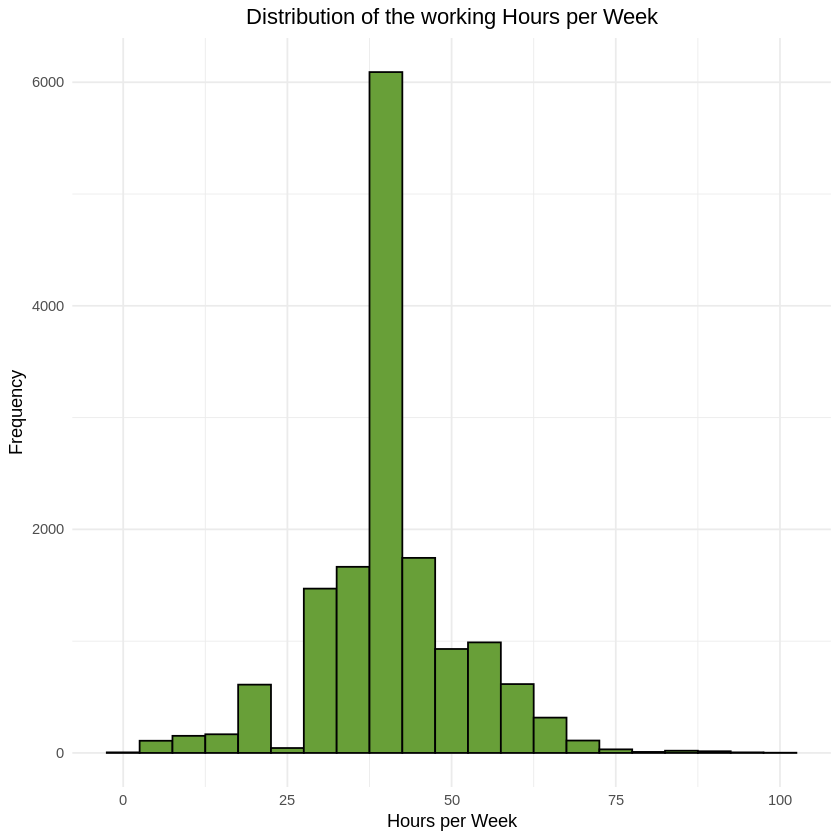

In [ ]:
# Histogram for hours.per.week variable
ggplot(train_data, aes(x = hours.per.week)) +
  geom_histogram(fill = "#689F38", color = "black", binwidth = 5, position = "dodge") +
  theme_minimal() +
  labs(title = "Distribution of the working Hours per Week",
       x = "Hours per Week",
       y = "Frequency")+
  theme(plot.title = element_text(hjust = 0.5))

In [ ]:
mean(dataset$hours.per.week)
median(dataset$hours.per.week)

[1] 40.11382

[1] 39

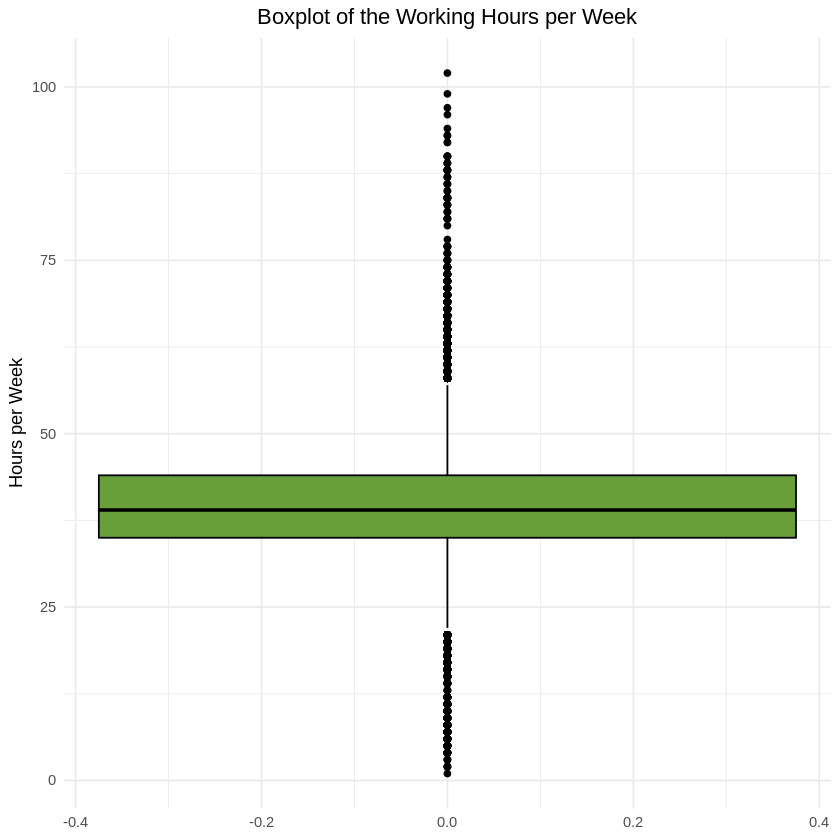

In [ ]:
# Boxplot of hours.per.week variable
ggplot(train_data, aes(y = hours.per.week)) +
  geom_boxplot(fill = "#689F38", color = "black") +
  theme_minimal() +
  labs(title = "Boxplot of the Working Hours per Week",
       y = "Hours per Week") +
  theme(plot.title = element_text(hjust = 0.5))

### Univariate Histograms

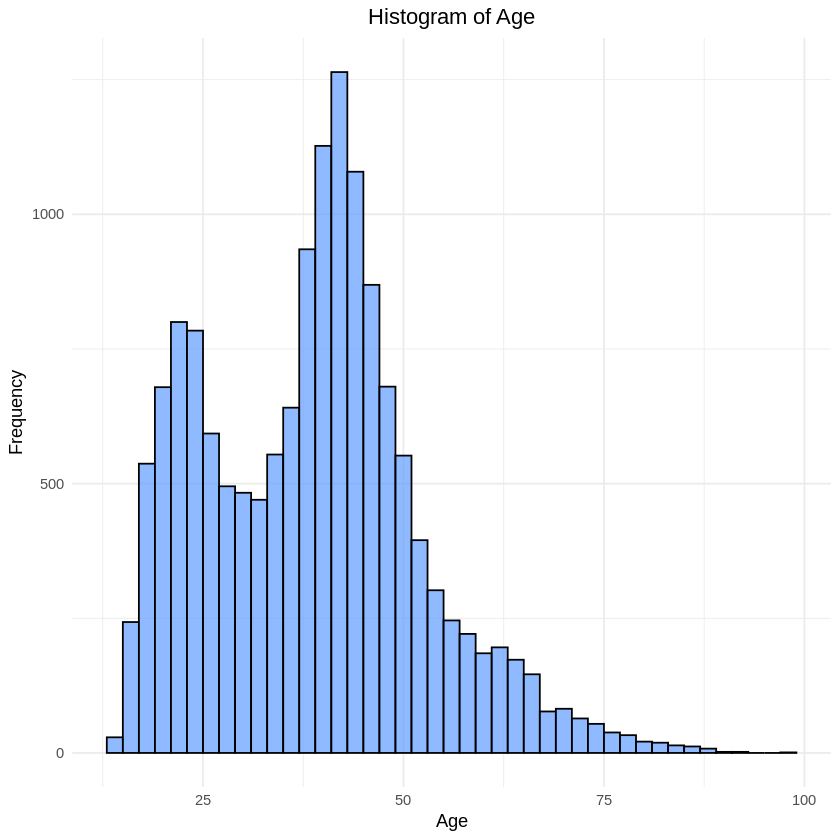

In [ ]:
###########Univariate Histograms

#age
ggplot(train_data, aes(x = age)) +
  geom_histogram(binwidth = 2, color = "black",fill = "#619CFF", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of Age",
       x = "Age",
       y = "Frequency")+
  theme(plot.title = element_text(hjust = 0.5))

### Choose a bin width that effectively captures the fnlwgt distribution

In [ ]:
data <- train_data$fnlwgt

# Calculate range
data_range <- max(data) - min(data)

# Determine number of bins
num_bins <- ceiling(sqrt(length(data)))

# Calculate bin width
bin_width <- data_range / num_bins

# Apply Freedman-Diaconis rule
IQR_value <- IQR(data)
bin_width_fd <- 2 * IQR_value * length(data)^(-1/3)

# Display results
cat("Recommended bin width:", bin_width, "\n")
cat("Bin width using Freedman-Diaconis rule:", bin_width_fd, "\n")


Recommended bin width: 5985.537 
Bin width using Freedman-Diaconis rule: 9577.042 


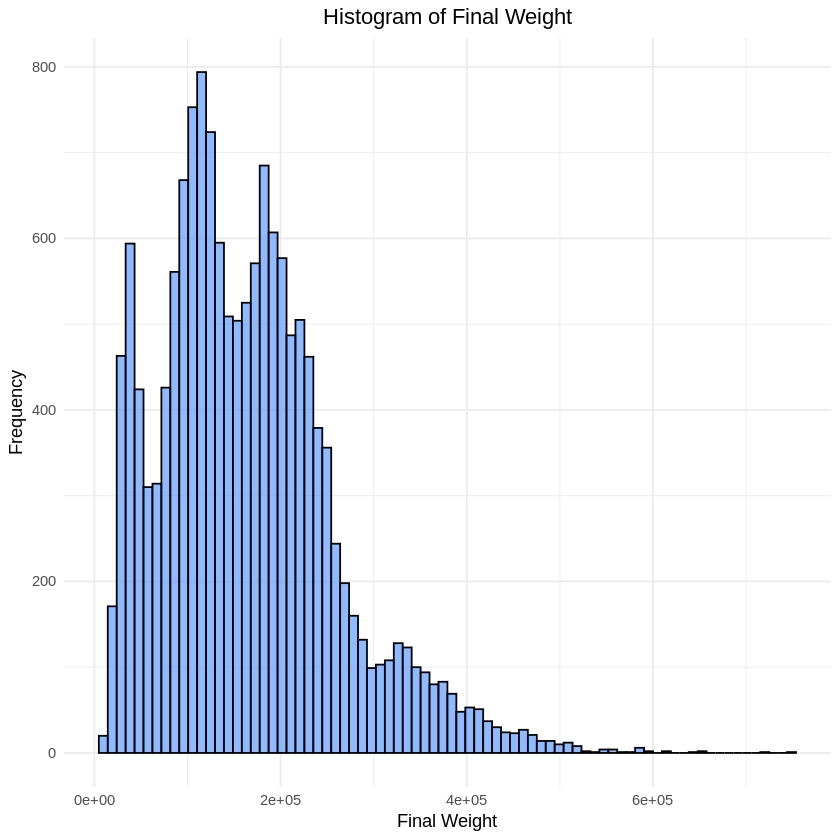

In [ ]:
#fnlwgt
ggplot(train_data, aes(x = fnlwgt)) +
  geom_histogram(binwidth = 9600, color = "black",fill = "#619CFF", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of Final Weight",
       x = "Final Weight",
       y = "Frequency")+
  theme(plot.title = element_text(hjust = 0.5))

Choose a bin width that effectively captures the education.num distribution

In [ ]:
data1 <- train_data$education.num
# Calculate range
data_range <- max(data1) - min(data1)
# Determine number of bins
num_bins <- ceiling(sqrt(length(data1)))
# Calculate bin width
bin_width <- data_range / num_bins
# Apply Freedman-Diaconis rule(since our data is heavily skewed)
IQR_value <- IQR(data1)
bin_width_fd <- 2 * IQR_value * length(data1)^(-1/3)
# Display results
cat("Recommended bin width:", bin_width, "\n")
cat("Bin width using Freedman-Diaconis rule:", bin_width_fd, "\n")

Recommended bin width: 0.1138211 
Bin width using Freedman-Diaconis rule: 0.3236307 


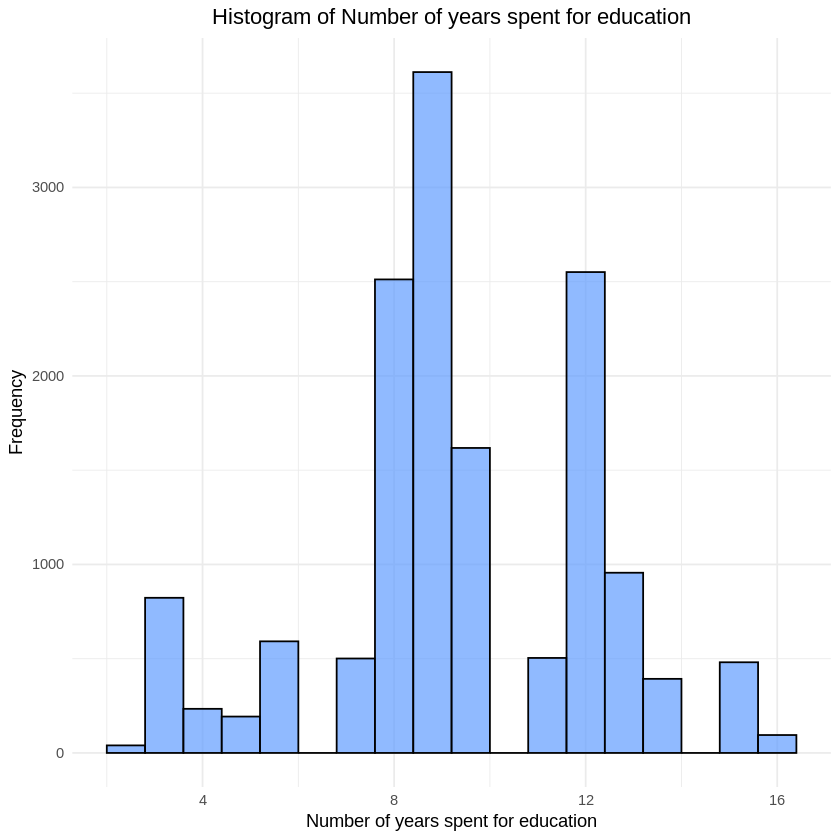

In [ ]:
#education.num
ggplot(train_data, aes(x = education.num)) +
  geom_histogram(binwidth = 0.8, color = "black",fill = "#619CFF", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of Number of years spent for education",
       x = "Number of years spent for education",
       y = "Frequency")+
  theme(plot.title = element_text(hjust = 0.5))

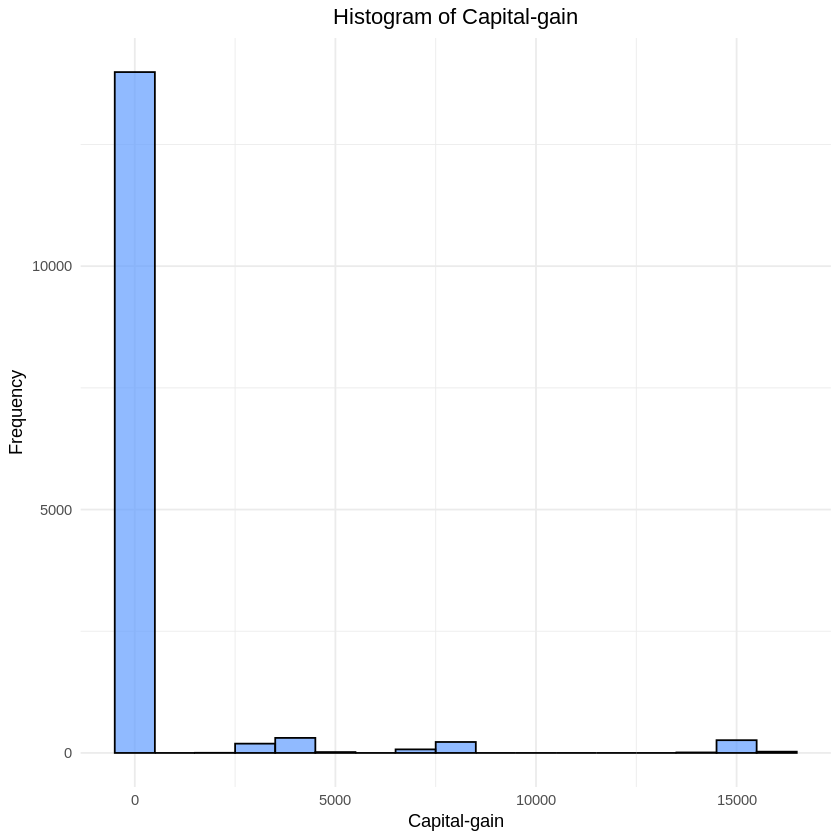

In [ ]:
#capital.gain
ggplot(train_data, aes(x = capital.gain)) +
  geom_histogram(binwidth = 1000, color = "black",fill = "#619CFF", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of Capital-gain",
       x = "Capital-gain",
       y = "Frequency")+
  theme(plot.title = element_text(hjust = 0.5))

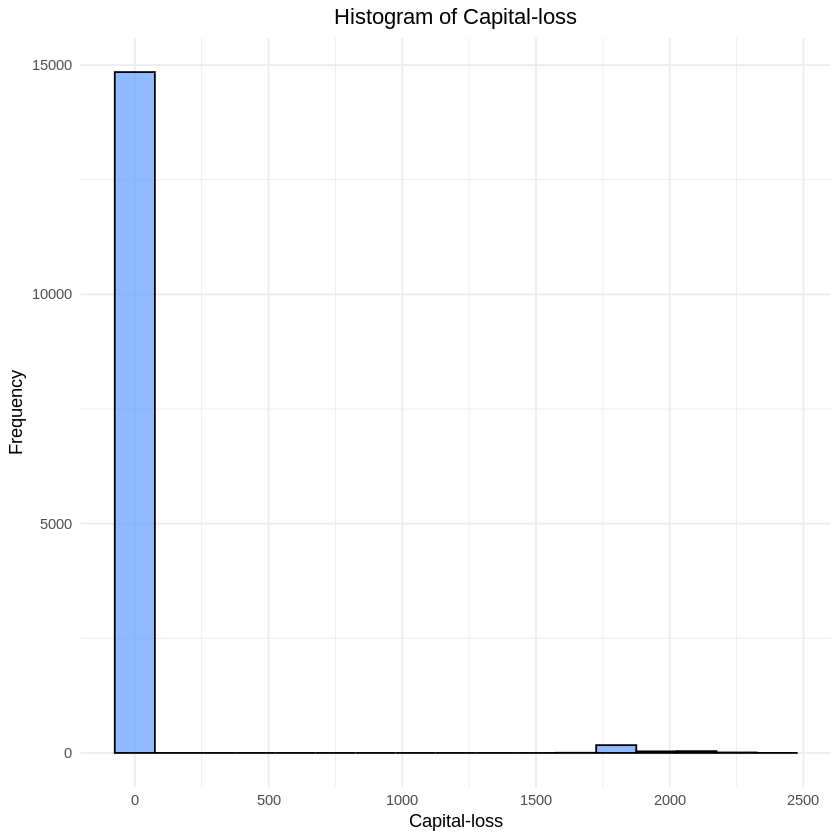

In [ ]:
#capital.loss
ggplot(train_data, aes(x = capital.loss)) +
  geom_histogram(binwidth = 150, color = "black",fill = "#619CFF", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of Capital-loss",
       x = "Capital-loss",
       y = "Frequency")+
  theme(plot.title = element_text(hjust = 0.5))

### Univariate Boxplots

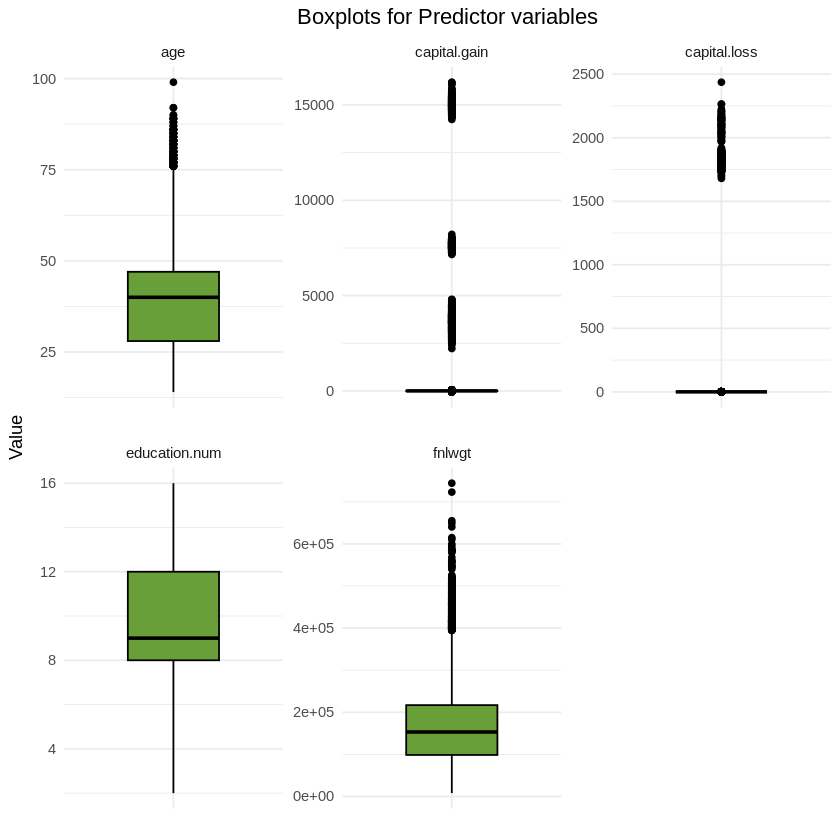

In [ ]:
#Reshape the data for boxplots
train_data_long = gather(train_data, key = "Variable", value = "value",
                         age, fnlwgt, education.num, capital.gain,
                         capital.loss)

ggplot(train_data_long, aes(x = "", y = value, fill = Variable))+
  geom_boxplot(color = "black", fill = "#689F38", width = 0.5)+
  labs(title = "Boxplots for Predictor variables", x = NULL, y = "Value")+
  theme_minimal()+
  facet_wrap(~Variable, scales = "free", ncol = 3)+
  theme(strip.text.x = element_text(size = 9),
        plot.title = element_text(hjust = 0.5))